In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

**Veri üretme**

In [2]:
n = 100   # Örneklem sayısını 100 olarak belirttik

np.random.seed(123) #tekrarlanabilirlik için
yas = np.random.randint(18, 81, n)  # Veri setinde yer alacak değişkenlerden ilki "yaş"  en küçük 18 en büyük 80 arasıolacak şekilde tanımladığımız n kadar
sigara = np.random.choice(['Kullanıyor', 'Kullanmıyor'], n, p=[0.3, 0.7])  # ikinci değişken sigara kullanım durumu, nominal kullanıyor kullanmıyor şeklinde oranı da %30 a %70
uyku_saati = np.round(np.random.normal(7, 1.2, n), 1)  # üçüncü değişken uyku saati, ortalam 7, ss 1.2, bu virgülsen sonra sadece bir basamak kalsın diye round fonksiyonu ekledim
egitim_duzeyi = np.random.choice(['İlkokul', 'Lise', 'Lisans', 'Lisansüstü'], n, p=[0.1, 0.3, 0.5, 0.1]) # dördüncü değişken eğitim düzeyi, kategorik değişken hangi eğitim düzeylerini ve yüzdelerini verdim, en çok lisansa atadım

egitim_etkisi = {'İlkokul': 20, 'Lise': 30, 'Lisans': 40, 'Lisansüstü': 45} #diğer değişkenimiz sağlık okuryazarlığı olacağı için ve eğitimle normalde ilşkili olduğu için,  ortalamalarını buna göre belirlendi
saglik_okuryazarligi = [np.clip(np.random.normal(egitim_etkisi[e], 5), 0, 50) for e in egitim_duzeyi] # beşinci değişken sağlık okuryazarlığı bu 0-50 arası puan alan bir ölçekpuanı olarak tasarlandı
#.clip ile 0-50 arası puan verecek, eğitim düzeyine göre eğitim etkisinde belirlenen ortalamalara standart sapma 5 olacak şekilde her bir eleman için döngüye alarak puan atayacak

saglik_durumu = []     # Son değişken sağlık durumu 1-10 arası puanlanan bir ölçek gibi, burasıda kendi başına yaparsak anlamsız bir veri seti çıkacağından yaş, sigara ve uykudan etkilenecek şekilde ayarlıyoruz.
for i in range(n):     # her bir örneklem için yaş 50 üstüyse (if) -2 puan, sigara kullanıyorsa -2 puan, uyku saati 6 saatin altındaysa -1 puan düşsün dedik
    skor = 10
    if yas[i] > 50: skor -= 2
    if sigara[i] == 'Kullanıyor': skor -= 2
    if uyku_saati[i] < 6: skor -= 1
    skor += np.random.normal(0, 1)                  # belirlenecek skorlara biraz hata eklemek ve gerçek hayata yaklaştırmak adına ortalama 0 ve ss 1 şeklinde bir ekleme yapıldı
    saglik_durumu.append(np.clip(round(skor, 1), 1, 10))        #puanların virgülden sonra 1 basamak olacak şekilde 1-10 arasında değişeceği belirtilerek hesaplanan skorlar sağlık durumu arrayine eklenecek

df = pd.DataFrame({
    'Yaş': yas,
    'Sigara_Kullanimi': sigara,
    'Uyku_Saati': uyku_saati,
    'Egitim_Duzeyi': egitim_duzeyi,
    'Saglik_Okuryazarligi': saglik_okuryazarligi,
    'Genel_Saglik_Puani': saglik_durumu
})  # bütün değişkenler df adı altında data frame olarak birleştirildi

print(df.head()) #ilk 5 satırı görmek için

   Yaş Sigara_Kullanimi  Uyku_Saati Egitim_Duzeyi  Saglik_Okuryazarligi  \
0   80      Kullanmıyor         7.6        Lisans             45.185648   
1   63      Kullanmıyor         7.6          Lise             28.883033   
2   80       Kullanıyor         5.5          Lise             27.196607   
3   20      Kullanmıyor         6.5        Lisans             41.971150   
4   46       Kullanıyor         7.9        Lisans             41.039673   

   Genel_Saglik_Puani  
0                 7.2  
1                 6.5  
2                 6.8  
3                10.0  
4                 8.8  


In [3]:
df.info() #veri yapısını kontrol etmek amacıyla info koduyla incelendi 6 değişken, 100 satır, 2 kategorik, bir integer, 3 ondalık içeren veri var sürekli değişken de diyebiliriz
#ayrıca hiçbir veride eksiklik olmadığınıda buradan görebiliyoruz

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Yaş                   100 non-null    int32  
 1   Sigara_Kullanimi      100 non-null    object 
 2   Uyku_Saati            100 non-null    float64
 3   Egitim_Duzeyi         100 non-null    object 
 4   Saglik_Okuryazarligi  100 non-null    float64
 5   Genel_Saglik_Puani    100 non-null    float64
dtypes: float64(3), int32(1), object(2)
memory usage: 4.4+ KB


<Axes: xlabel='Yaş'>

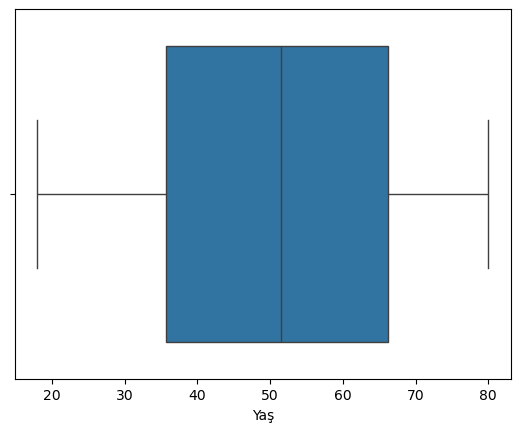

In [4]:
sns.boxplot(data=df, x='Yaş')  #numerik değişkenler için sırasıyla boxplot çizdirip uç değerlere bakıyoruz, yaşta aykırı değer bulunmuyor

<Axes: xlabel='Uyku_Saati'>

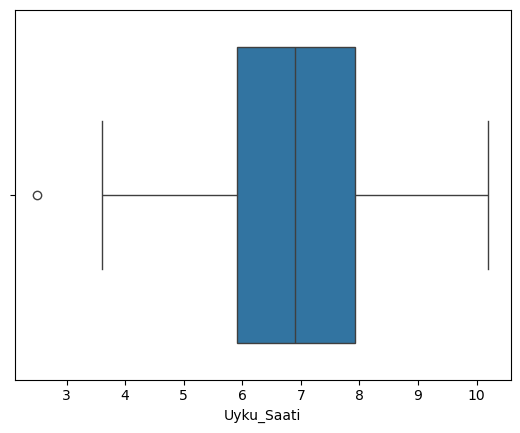

In [5]:
sns.boxplot(data=df, x="Uyku_Saati")  #numerik değişkenler için sırasıyla boxplot çizdirip uç değerlere bakıyoruz, uyku saatinde aykırı değer bulunmuyor


<Axes: xlabel='Saglik_Okuryazarligi'>

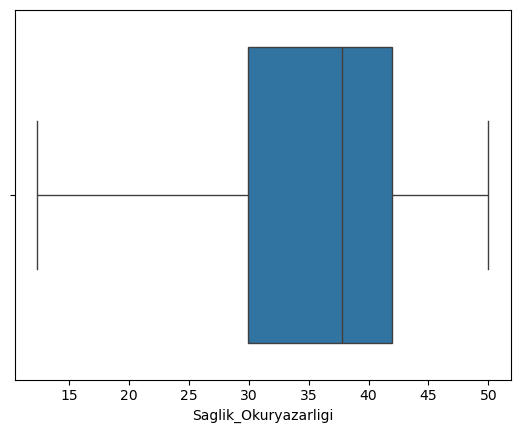

In [6]:
sns.boxplot(data=df, x='Saglik_Okuryazarligi')  #numerik değişkenler için sırasıyla boxplot çizdirip uç değerlere bakıyoruz, sağlık okur yazarlığında aykırı değer bulunmuyor


<Axes: xlabel='Genel_Saglik_Puani'>

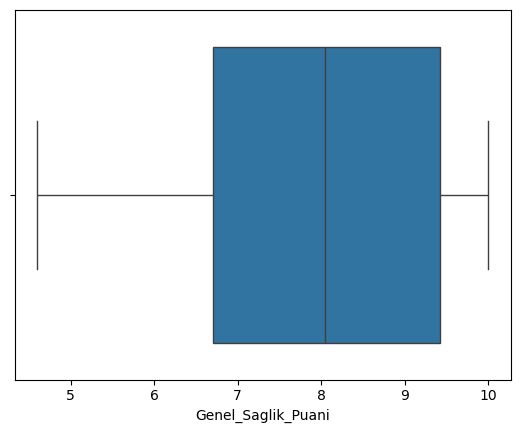

In [7]:
sns.boxplot(data=df, x="Genel_Saglik_Puani")  #numerik değişkenler için sırasıyla boxplot çizdirip uç değerlere bakıyoruz, genel sağlık puanında aykırı değer bulunmuyor

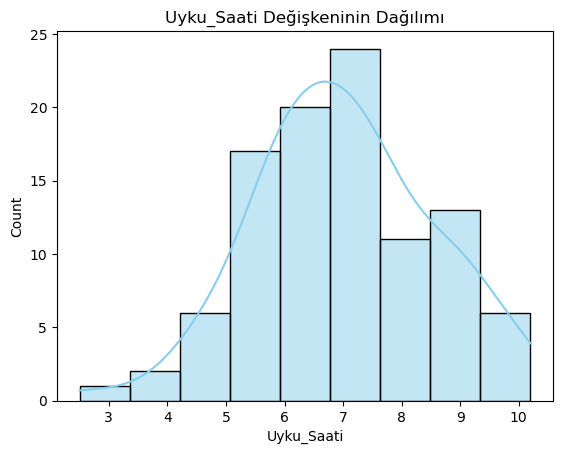

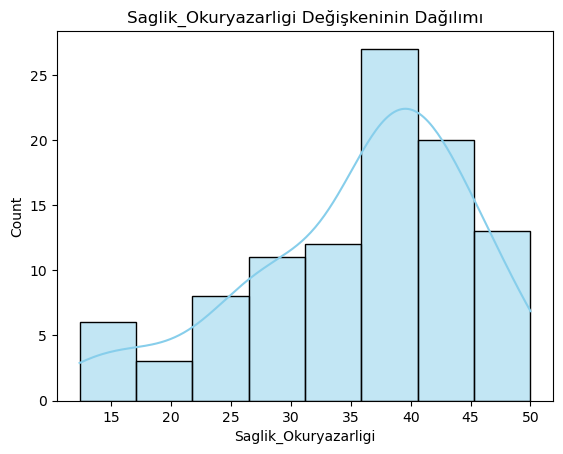

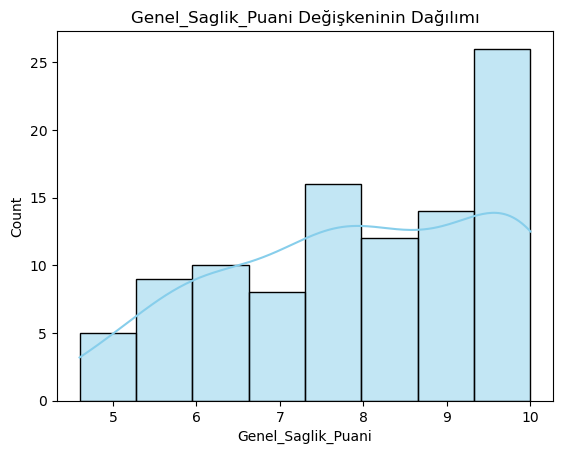

In [8]:
#numerik değerlerin dağılım grafiğini inceleyelim aslında tam normal dağılıma yakınlar basıklık (yaşta), sivrilik (uyku saatinde), hafif sola çarpık sağlık okur yazarlığı), genel sağlık puanıda sola çarpık olabilir belki
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns  #numericleri ayrı bir data frame olarak seçtik

for col in numeric_cols:                     # Her  değişken için ayrı bir dağılım grafiği çizelcek
    sns.histplot(df[col], kde=True, color='skyblue')   #histogram renk ve kde eğirisi olacak
    plt.title(f'{col} Değişkeninin Dağılımı')    #başlık kolon ismi ardından değişkeninin dağılımı
    plt.show()    #gösterir

In [9]:
# normalliği sağlayıp sağlamadığına bakmak için z skorlarını hesaplayıp  |3| büyük değerleri inceleyeceğiz, bu değerler normalliği bozuyor olabilir diye
df_numeric = df.select_dtypes(include=['float64', 'int64'])   #numeric değişkenlerin yer aldığı data frame oluşturuldı
df_zscore = (df_numeric - df_numeric.mean()) / df_numeric.std() #z skoru her bir değer için ortalamayı çıkarıp standart sapmaya bölünmesi ile hesaplanıyor

print(df_zscore.head()) #yeni oluşan df_zscore data framini inceliyoruz ilk 5 satırı

   Uyku_Saati  Saglik_Okuryazarligi  Genel_Saglik_Puani
0    0.393988              1.034090           -0.475752
1    0.393988             -0.739362           -0.910512
2   -0.991901             -0.922817           -0.724186
3   -0.331953              0.684406            1.263289
4    0.591973              0.583077            0.517986


In [10]:
# |3|'ten büyük olanları işaretleyecek bi koşul yazdık
kosul = np.abs(df_zscore) > 3    #.abs absolut değeri verir
aykiri_satirlar = df[kosul.any(axis=1)]   # Herhangi bir sütunda (axis=1) True olan satırları filtreleyecek
print("Aykırı Değer İçeren Satır Sayısı:", len(aykiri_satirlar)), #bu ayrıkı değerlerin kaç tane olduğunu bize verecek
print(aykiri_satirlar)  #aykırı değer olmadığını görüyoruz.

Aykırı Değer İçeren Satır Sayısı: 0
Empty DataFrame
Columns: [Yaş, Sigara_Kullanimi, Uyku_Saati, Egitim_Duzeyi, Saglik_Okuryazarligi, Genel_Saglik_Puani]
Index: []


In [11]:
#float ve integer olan sütunların ortalama, standart sapma, min-max ve çeyreklik değerlerini içeren betimleyici istatistik tablosunu yaptıracağız şimdide, virgülden sonra 1 basamak versin diye np.round kullandım
df_ozet = np.round((df.describe().T),1)
df_ozet

,count,mean,std,min,25%,50%,75%,max
Yaş,100.0,50.8,18.4,18.0,35.8,51.5,66.2,80.0
Uyku_Saati,100.0,7.0,1.5,2.5,5.9,6.9,7.9,10.2
Saglik_Okuryazarligi,100.0,35.7,9.2,12.4,29.9,37.8,42.0,50.0
Genel_Saglik_Puani,100.0,8.0,1.6,4.6,6.7,8.0,9.4,10.0


In [12]:
#sayısal olmayan diğer sutunlarda da hangi ifadeler değerler var görmek için frekans dağılımına bakacağız değişkenlerin

kategorik_ozet = df.describe(include=['object']).T

print("=== KATEGORİK DEĞİŞKENLER ===\n")

print(kategorik_ozet)

=== KATEGORİK DEĞİŞKENLER ===

                 count unique          top freq
Sigara_Kullanimi   100      2  Kullanmıyor   67
Egitim_Duzeyi      100      4       Lisans   60


In [13]:
#değişkenleri daha da açabilmek için dağılımları görebilmek için kategorik sutunları seçip, her birinin değerlerini getirtiyoruz
kategorik_sutunlar = df.select_dtypes(include=['object']).columns

print("=== TÜM KATEGORİK DEĞİŞKENLERİN FREKANS ANALİZİ ===\n")  #başlık 

for sutun in kategorik_sutunlar:
    print(f"--- {sutun} Dağılımı ---")
    print(df[sutun].value_counts())   # Her sütun için var olan değerleri ve kullanım sayısını getirir
    print("-" * 40)

=== TÜM KATEGORİK DEĞİŞKENLERİN FREKANS ANALİZİ ===

--- Sigara_Kullanimi Dağılımı ---
Sigara_Kullanimi
Kullanmıyor    67
Kullanıyor     33
Name: count, dtype: int64
----------------------------------------
--- Egitim_Duzeyi Dağılımı ---
Egitim_Duzeyi
Lisans        60
Lise          22
İlkokul       11
Lisansüstü     7
Name: count, dtype: int64
----------------------------------------


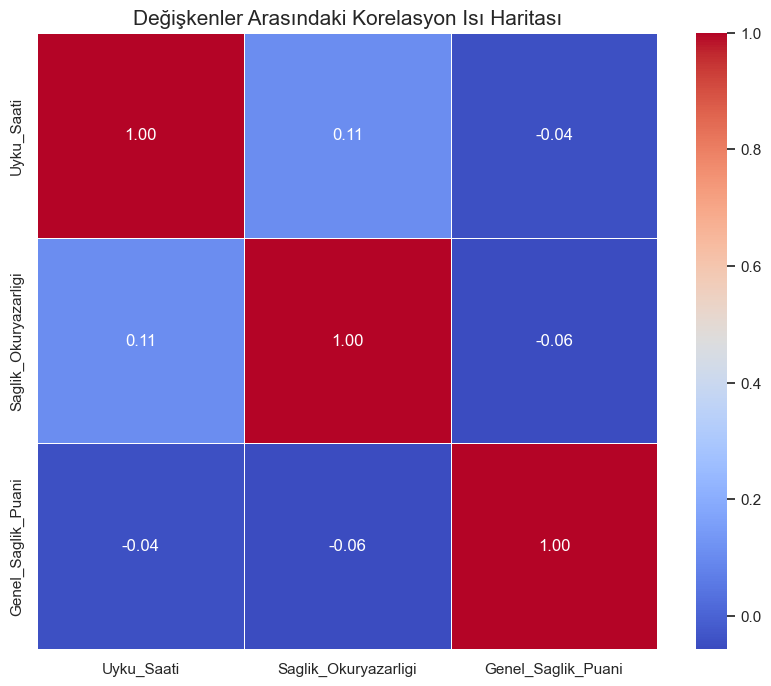

In [15]:
#görselleştirmek ve aradaki ilişkileri kestirebilmek için önden bir korelasyon içeren heatmap yapabiliriz, hep negatif ilişki çıktı, sağlık okur yazarlığı da şaşırttı açıkcası normalde pozitif olması lazım ama sonuçla üretirken böyle bir koşul vermedik

sns.set_theme(style="whitegrid") # Grafik stil ayarı

plt.figure(figsize=(10, 8)) #korelasyon için sayısal verileri seçmek gerekiyor
correlation_matrix = df[numeric_cols].corr()  #yukarıda numeric_cols u tanımlamıştık, korelasyon matrixini verecek

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Değişkenler Arasındaki Korelasyon Isı Haritası', fontsize=15)
plt.savefig('heatmap_korelasyon.png', bbox_inches='tight')
plt.show()

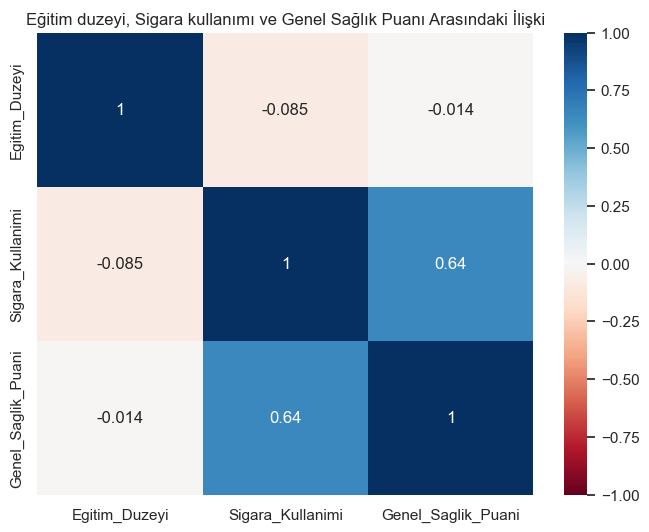

In [16]:
#kategorik değişkenler ile genel sağlık durumu için ise spearman korelasyon analizi yapmak gerekiyor ama bunun için objectleri label encoding yapacağız,
#analiz sonunda görüyoruz ki sigara kullanmamanın sağlık puanı ile ilişkisi yüksek düzeyde pozitif yönde ilişkisi var

secilen_sutunlar = ['Egitim_Duzeyi', 'Sigara_Kullanimi', 'Genel_Saglik_Puani'] #analize dahil edilecek sutunllar
analiz_df = df[secilen_sutunlar].copy()  #veriden bu sutunlar çekiildi

sigara_mapping = {'Kullanmıyor': 1, 'Kullanıyor': 0} # Sigara Kullanımı Eşleştirmesi
egitim_mapping = {'İlkokul': 1, 'Lise': 2, 'Lisans': 3, 'Lisansüstü': 4} # Eğitim Durumu Eşleştirmesi

analiz_df['Sigara_Kullanimi'] = analiz_df['Sigara_Kullanimi'].map(sigara_mapping)
analiz_df['Egitim_Duzeyi'] = analiz_df['Egitim_Duzeyi'].map(egitim_mapping)

korelasyon_matrisi = analiz_df.corr(method='spearman') #korelasyon yöntemi

plt.figure(figsize=(8, 6))  #heatmap yapılacak
sns.heatmap(korelasyon_matrisi, annot=True, cmap='RdBu', vmin=-1, vmax=1)
plt.title("Eğitim duzeyi, Sigara kullanımı ve Genel Sağlık Puanı Arasındaki İlişki")
plt.show()

## **Hazır veri setine dayalı veri ön işleme ve keşifsel analiz**

In [18]:
veri = pd.read_csv("C:/Users/Lenovo/Downloads/500_Cities__Local_Data_for_Better_Health__2019_release.csv") #veriyi yüklüyoruz, sağlıkla ilgili open acsees olan bu veri tabanı içinde USA eyaletleri ile ilgili hastalık  ve koruyucu davranış verileri bulunuyor

In [21]:
print(veri.head()) #verilerin nasıl göründüğüne ilk etapta bakmak istedim ilk 5 satırı üzerinden 24 değişken var

   Year StateAbbr   StateDesc   CityName GeographicLevel DataSource  \
0  2017        CA  California  Hawthorne    Census Tract      BRFSS   
1  2017        CA  California  Hawthorne            City      BRFSS   
2  2017        CA  California    Hayward            City      BRFSS   
3  2017        CA  California    Hayward            City      BRFSS   
4  2017        CA  California      Hemet            City      BRFSS   

              Category             UniqueID  \
0      Health Outcomes  0632548-06037602504   
1  Unhealthy Behaviors              0632548   
2      Health Outcomes              0633000   
3  Unhealthy Behaviors              0633000   
4           Prevention              0633182   

                                             Measure Data_Value_Unit  ...  \
0             Arthritis among adults aged >=18 Years               %  ...   
1       Current smoking among adults aged >=18 Years               %  ...   
2  Coronary heart disease among adults aged >=18 ...       

In [22]:
veri.info() #veri yapısını anlamak için info koduyla incelendi ve toplamda 810103 satır ve 24 değişken olduğu görüldü
#değişkenler: yıl, eyalet kısaltmaları ve tm adı, şehir isimleri, coğrafik düzey (şehir, mahalle vs), veri kaynağı, ölçümün türü,  sağlık verileri gibi
#verilerin 2 tanesi integer, 5 tanesi float, 17 tanesi object (metin ve karma) veri tipindedir. 24 kolon ve 810103 satır bulunmaktadır. 15. ve 16. sutun çok fazla eksik veri içeriyor, 12., 13. ve 14. sutunlarda eksik veriler var

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 810103 entries, 0 to 810102
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Year                        810103 non-null  int64  
 1   StateAbbr                   810103 non-null  object 
 2   StateDesc                   810103 non-null  object 
 3   CityName                    810047 non-null  object 
 4   GeographicLevel             810103 non-null  object 
 5   DataSource                  810103 non-null  object 
 6   Category                    810103 non-null  object 
 7   UniqueID                    810103 non-null  object 
 8   Measure                     810103 non-null  object 
 9   Data_Value_Unit             810103 non-null  object 
 10  DataValueTypeID             810103 non-null  object 
 11  Data_Value_Type             810103 non-null  object 
 12  Data_Value                  787311 non-null  float64
 13  Low_Confidence

In [23]:
veri.drop(columns=['Data_Value_Footnote_Symbol', 'Data_Value_Footnote'], axis=1, inplace=True) #öncelikle "Data_Value_Footnote_Symbol" ve "Data_Value_Footnote" sutunlarını çok fazla eksik veri olduğu için çıkartıldı
veri.columns #çıkartıldığını kontrol amaçlı

Index(['Year', 'StateAbbr', 'StateDesc', 'CityName', 'GeographicLevel',
       'DataSource', 'Category', 'UniqueID', 'Measure', 'Data_Value_Unit',
       'DataValueTypeID', 'Data_Value_Type', 'Data_Value',
       'Low_Confidence_Limit', 'High_Confidence_Limit', 'PopulationCount',
       'GeoLocation', 'CategoryID', 'MeasureId', 'CityFIPS', 'TractFIPS',
       'Short_Question_Text'],
      dtype='object')

In [24]:
#eksik verilerin olduğu kolonları anlamak için içeriğine bakacağım
veri[['Data_Value', 'Low_Confidence_Limit', 'High_Confidence_Limit']].head()

,Data_Value,Low_Confidence_Limit,High_Confidence_Limit
0,14.6,13.9,15.2
1,15.4,15.0,15.9
2,4.8,4.7,4.8
3,24.2,24.1,24.4
4,78.0,77.6,78.3


In [25]:
#eksik verileri doldurma veride 22794 adet eksik veri var yukarıda bu total verinin yaklaşık %0.03 gibi bir kısmını 
#oluşturduğundan çıkarıladabilir, dolduruladabilir, beksik veriyi tamamlamayı tercih ettik
cols_to_fix = ['Data_Value', 'Low_Confidence_Limit', 'High_Confidence_Limit']  # sonrasında 12., 13. ve 14. kolonlarındaki 
#eksik verileri tamamlamak için sadece ortalama yerine, bulunduğu eyaletin (StateAbbr) ve ölçüm türünün (MeasureId)
#ortalamasına göre dolduracağız, çünkü bölgelerin sağlık profilleri birbirinden farklı olabilir

for col in cols_to_fix:   #boşluk olan her kolona aynı işlemi uygulayacağımızdan döngüye alıyoruz
    veri[col] = veri[col].fillna(veri.groupby(['StateAbbr', 'MeasureId'])[col].transform('mean'))  #fillna eksik veriyi buluyor, 
    #groupby ile stateAbbr ve MEasuredID verileri gruplanıyor transform ile bu grupların ortalamaları eksik verilere kaydedilecek

print(veri[cols_to_fix].isnull().sum()) #işlem sonunda hala boş veri kalıp kalmadığını kontrol amaçlı

Data_Value               2349
Low_Confidence_Limit     2349
High_Confidence_Limit    2349
dtype: int64


In [ ]:
#hiç ölçüm yapılmayan eyalet ya da ölçüm olabilir 2349 veri hala boş
#bunu bulmak için eksiğin hangi eyalet ve MeasureID sine ait olduğuna baktık
eksik_ozet = veri[veri['Data_Value'].isnull()].groupby(['StateAbbr', 'MeasureId']).size().reset_index(name='Eksik_Sayisi') #.isnull() eksikleri bulacak
#size() sayısını verecek, reset_index eksik sayısı isimli yeni bir sutun açacak
print(eksik_ozet)

  StateAbbr MeasureId  Eksik_Sayisi
0        AR   PAPTEST           130
1        AZ   PAPTEST          1059
2        CT   PAPTEST           236
3        MD   PAPTEST           202
4        NH   PAPTEST            51
5        RI   PAPTEST           107
6        VT   PAPTEST            13
7        WA   PAPTEST           551


In [ ]:
#8 eyalette paptest in eksik olduğunu görüyoruz. veri sayısına göre küçük bir veri diyebiliriz o zaman genel paptest ortalaması ile doldurabiliriz 
#paptestte eksik olduğu için genel diğer eyaletlerdeki paptest ortalamasıyla dolduralacak bu eksik veriler
paptest_mean = veri[veri['MeasureId'] == 'PAPTEST']['Data_Value'].mean()

veri['Data_Value'] = veri['Data_Value'].fillna(paptest_mean)
veri['Low_Confidence_Limit'] = veri['Low_Confidence_Limit'].fillna(veri[veri['MeasureId'] == 'PAPTEST']['Low_Confidence_Limit'].mean())
veri['High_Confidence_Limit'] = veri['High_Confidence_Limit'].fillna(veri[veri['MeasureId'] == 'PAPTEST']['High_Confidence_Limit'].mean())

veri.isnull().sum()  #hala eksik veriler var ama bunlar analizde kullanılmayacak o sebeple kalabilir, TractFIPS mahalle kodu, 
                    #getLocationda eksik sehirlerin geografik bilgileri

,0
Year,0
StateAbbr,0
StateDesc,0
CityName,56
GeographicLevel,0
DataSource,0
Category,0
UniqueID,0
Measure,0
Data_Value_Unit,0


In [26]:
#eksik veri kalmadı, float ve integer olan sütunların ortalama, standart sapma, min-max ve çeyreklik değerlerini içeren 
#betimleyici istatistik tablosunu yaptıracağız
veri_ozet = veri.describe().T
veri_ozet

,count,mean,std,min,25%,50%,75%,max
Year,810103.0,2.016716e+03,4.509056e-01,2.016000e+03,2.016000e+03,2.017000e+03,2.017000e+03,2.017000e+03
Data_Value,807754.0,3.138017e+01,2.597544e+01,3.000000e-01,1.000000e+01,2.290000e+01,4.600000e+01,9.570000e+01
Low_Confidence_Limit,807754.0,2.968996e+01,2.553305e+01,2.000000e-01,8.900000e+00,2.080000e+01,4.320000e+01,9.460000e+01
High_Confidence_Limit,807754.0,3.308433e+01,2.638173e+01,3.000000e-01,1.120000e+01,2.520000e+01,4.910000e+01,9.650000e+01
PopulationCount,810103.0,3.202413e+04,2.568489e+06,1.000000e+00,2.405000e+03,3.632000e+03,5.040000e+03,3.087455e+08
CityFIPS,810047.0,2.606307e+06,1.686183e+06,1.500300e+04,6.813440e+05,2.622000e+06,4.055000e+06,5.613900e+06
TractFIPS,782047.0,2.592907e+10,1.675378e+10,1.073000e+09,8.001009e+09,2.608100e+10,4.010911e+10,5.602100e+10


In [27]:
#daha anlaşılır olması için değerlerin floata çeviriyoruz, virgülden sonra iki basamak olacak, 
#birde CityFIPS ve TractFIPS sayısal görünsede aslında posta kodu gibi değerler bunlar o sebeple çıkarılacak,
#year da aslında sadece iki yılda 2016 ve 2017 de girilen verileri kapsıyor
pd.set_option('display.float_format', lambda x: '%.2f' % x)

veri.drop(columns=['CityFIPS', 'TractFIPS']).describe().T

,count,mean,std,min,25%,50%,75%,max
Year,810103.00,2016.72,0.45,2016.00,2016.00,2017.00,2017.00,2017.00
Data_Value,807754.00,31.38,25.98,0.30,10.00,22.90,46.00,95.70
Low_Confidence_Limit,807754.00,29.69,25.53,0.20,8.90,20.80,43.20,94.60
High_Confidence_Limit,807754.00,33.08,26.38,0.30,11.20,25.20,49.10,96.50
PopulationCount,810103.00,32024.13,2568489.10,1.00,2405.00,3632.00,5040.00,308745538.00


In [28]:
#sayısal olmayan diğer sutunlarda da hangi ifadeler değerler var görmek için frekans dağılımına bakacağız değişkenlerin

kategorik_ozet = veri.describe(include=['object']).T

print(kategorik_ozet)

                      count unique                                     top  \
StateAbbr            810103     52                                      CA   
StateDesc            810103     52                              California   
CityName             810047    474                                New York   
GeographicLevel      810103      3                            Census Tract   
DataSource           810103      1                                   BRFSS   
Category             810103      3                         Health Outcomes   
UniqueID             810103  28505                                 2684000   
Measure              810103     28  Arthritis among adults aged >=18 Years   
Data_Value_Unit      810103      1                                       %   
DataValueTypeID      810103      2                                  CrdPrv   
Data_Value_Type      810103      2                        Crude prevalence   
GeoLocation          810047  28504         (42.4934233034, -83.0

In [30]:
#değişkenleri daha da açabilmek için dağılımları görebilmek için kategorik sutunları seçip, her birinin top 10 değerini getirtiyoruz
kategorik_sutunlar = veri.select_dtypes(include=['object']).columns

print("=== TÜM KATEGORİK DEĞİŞKENLERİN FREKANS ANALİZİ ===\n")

for sutun in kategorik_sutunlar:
    print(f"--- {sutun} Dağılımı (Top 10) ---") 
    print(veri[sutun].value_counts().head(10)) # her sütun için ilk 10 değeri ve kullanım sayısını verecek
    print("-" * 40)

=== TÜM KATEGORİK DEĞİŞKENLERİN FREKANS ANALİZİ ===

--- StateAbbr Dağılımı (Top 10) ---
StateAbbr
CA    156778
TX     89422
NY     70133
FL     39025
IL     37458
AZ     29678
OH     24111
NC     23305
MI     21672
CO     20549
Name: count, dtype: int64
----------------------------------------
--- StateDesc Dağılımı (Top 10) ---
StateDesc
California       156778
Texas             89422
New York          70133
Florida           39025
Illinois          37458
Arizona           29678
Ohio              24111
North Carolin     23305
Michigan          21672
Colorado          20549
Name: count, dtype: int64
----------------------------------------
--- CityName Dağılımı (Top 10) ---
CityName
New York        59911
Los Angeles     28119
Chicago         22369
Houston         16787
Philadelphia    10707
Phoenix         10097
San Antonio      9145
Dallas           8959
Detroit          8335
San Diego        8315
Name: count, dtype: int64
----------------------------------------
--- GeographicLevel 

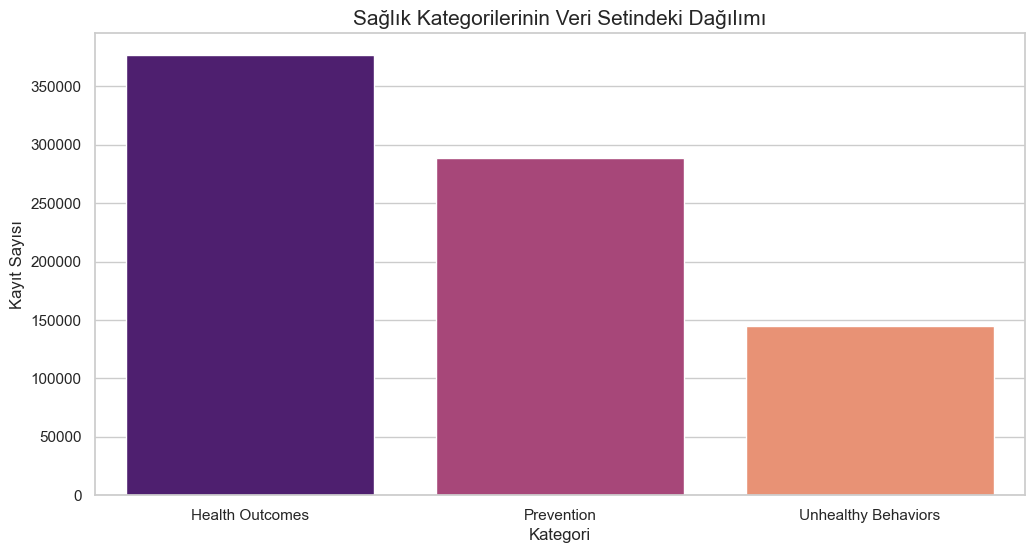

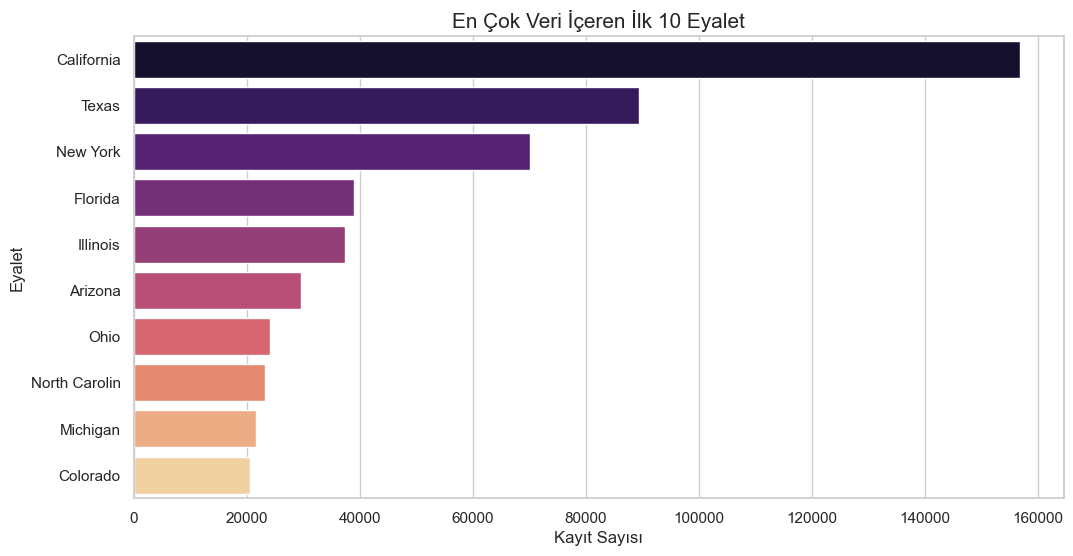

In [31]:
#kategorik verileri görselleştirelim
plt.figure(figsize=(12, 6))  #saglık kategorisi için
category_counts = veri['Category'].value_counts()
sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index, palette='magma', legend=False)

plt.title('Sağlık Kategorilerinin Veri Setindeki Dağılımı', fontsize=15)
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('Kayıt Sayısı', fontsize=12)
plt.savefig('bar_kategoriler.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6)) #eyaletde çok fazla veri olduğu için ilk 10 eyalet için bar plot
state_counts = veri['StateDesc'].value_counts().head(10)
sns.barplot(x=state_counts.values, y=state_counts.index, hue=state_counts.index, palette='magma', legend=False)

plt.title('En Çok Veri İçeren İlk 10 Eyalet', fontsize=15)
plt.xlabel('Kayıt Sayısı', fontsize=12)
plt.ylabel('Eyalet', fontsize=12)
plt.savefig('bar_eyaletler.png', bbox_inches='tight')
plt.show()

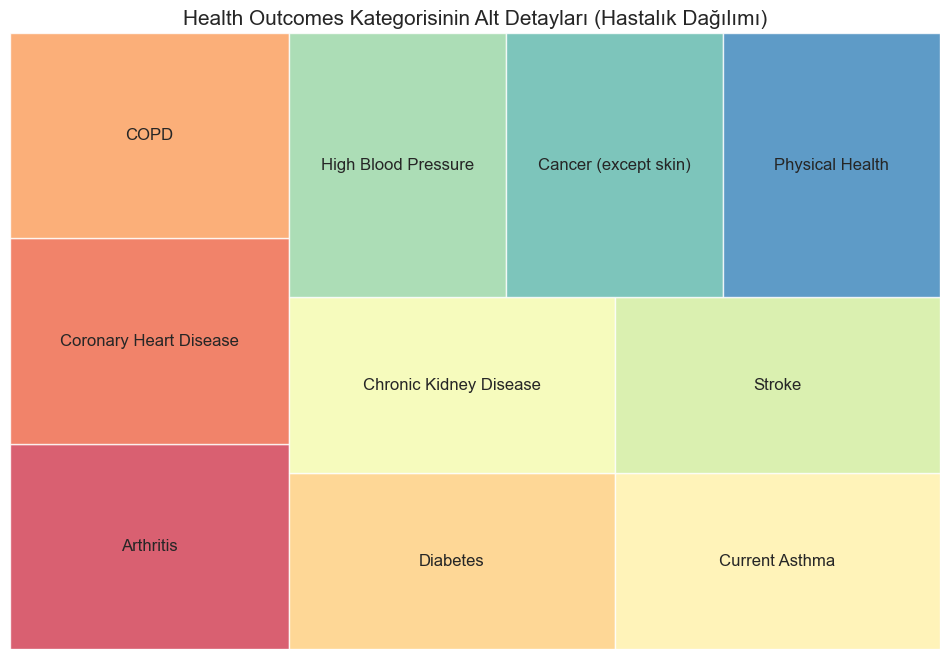

In [33]:
#kategori için barchart hiç bilgi vermedi sanki, daha bilgi veren bir treemap daha çok bilgi verebilir
!pip install squarify
import squarify

sub_category = veri[veri['Category'] == 'Health Outcomes']['Short_Question_Text'].value_counts().head(10)

plt.figure(figsize=(12, 8))
squarify.plot(sizes=sub_category.values, label=sub_category.index, alpha=0.8, color=sns.color_palette("Spectral", len(sub_category)))
plt.title('Health Outcomes Kategorisinin Alt Detayları (Hastalık Dağılımı)', fontsize=15)
plt.axis('off')
plt.show() 


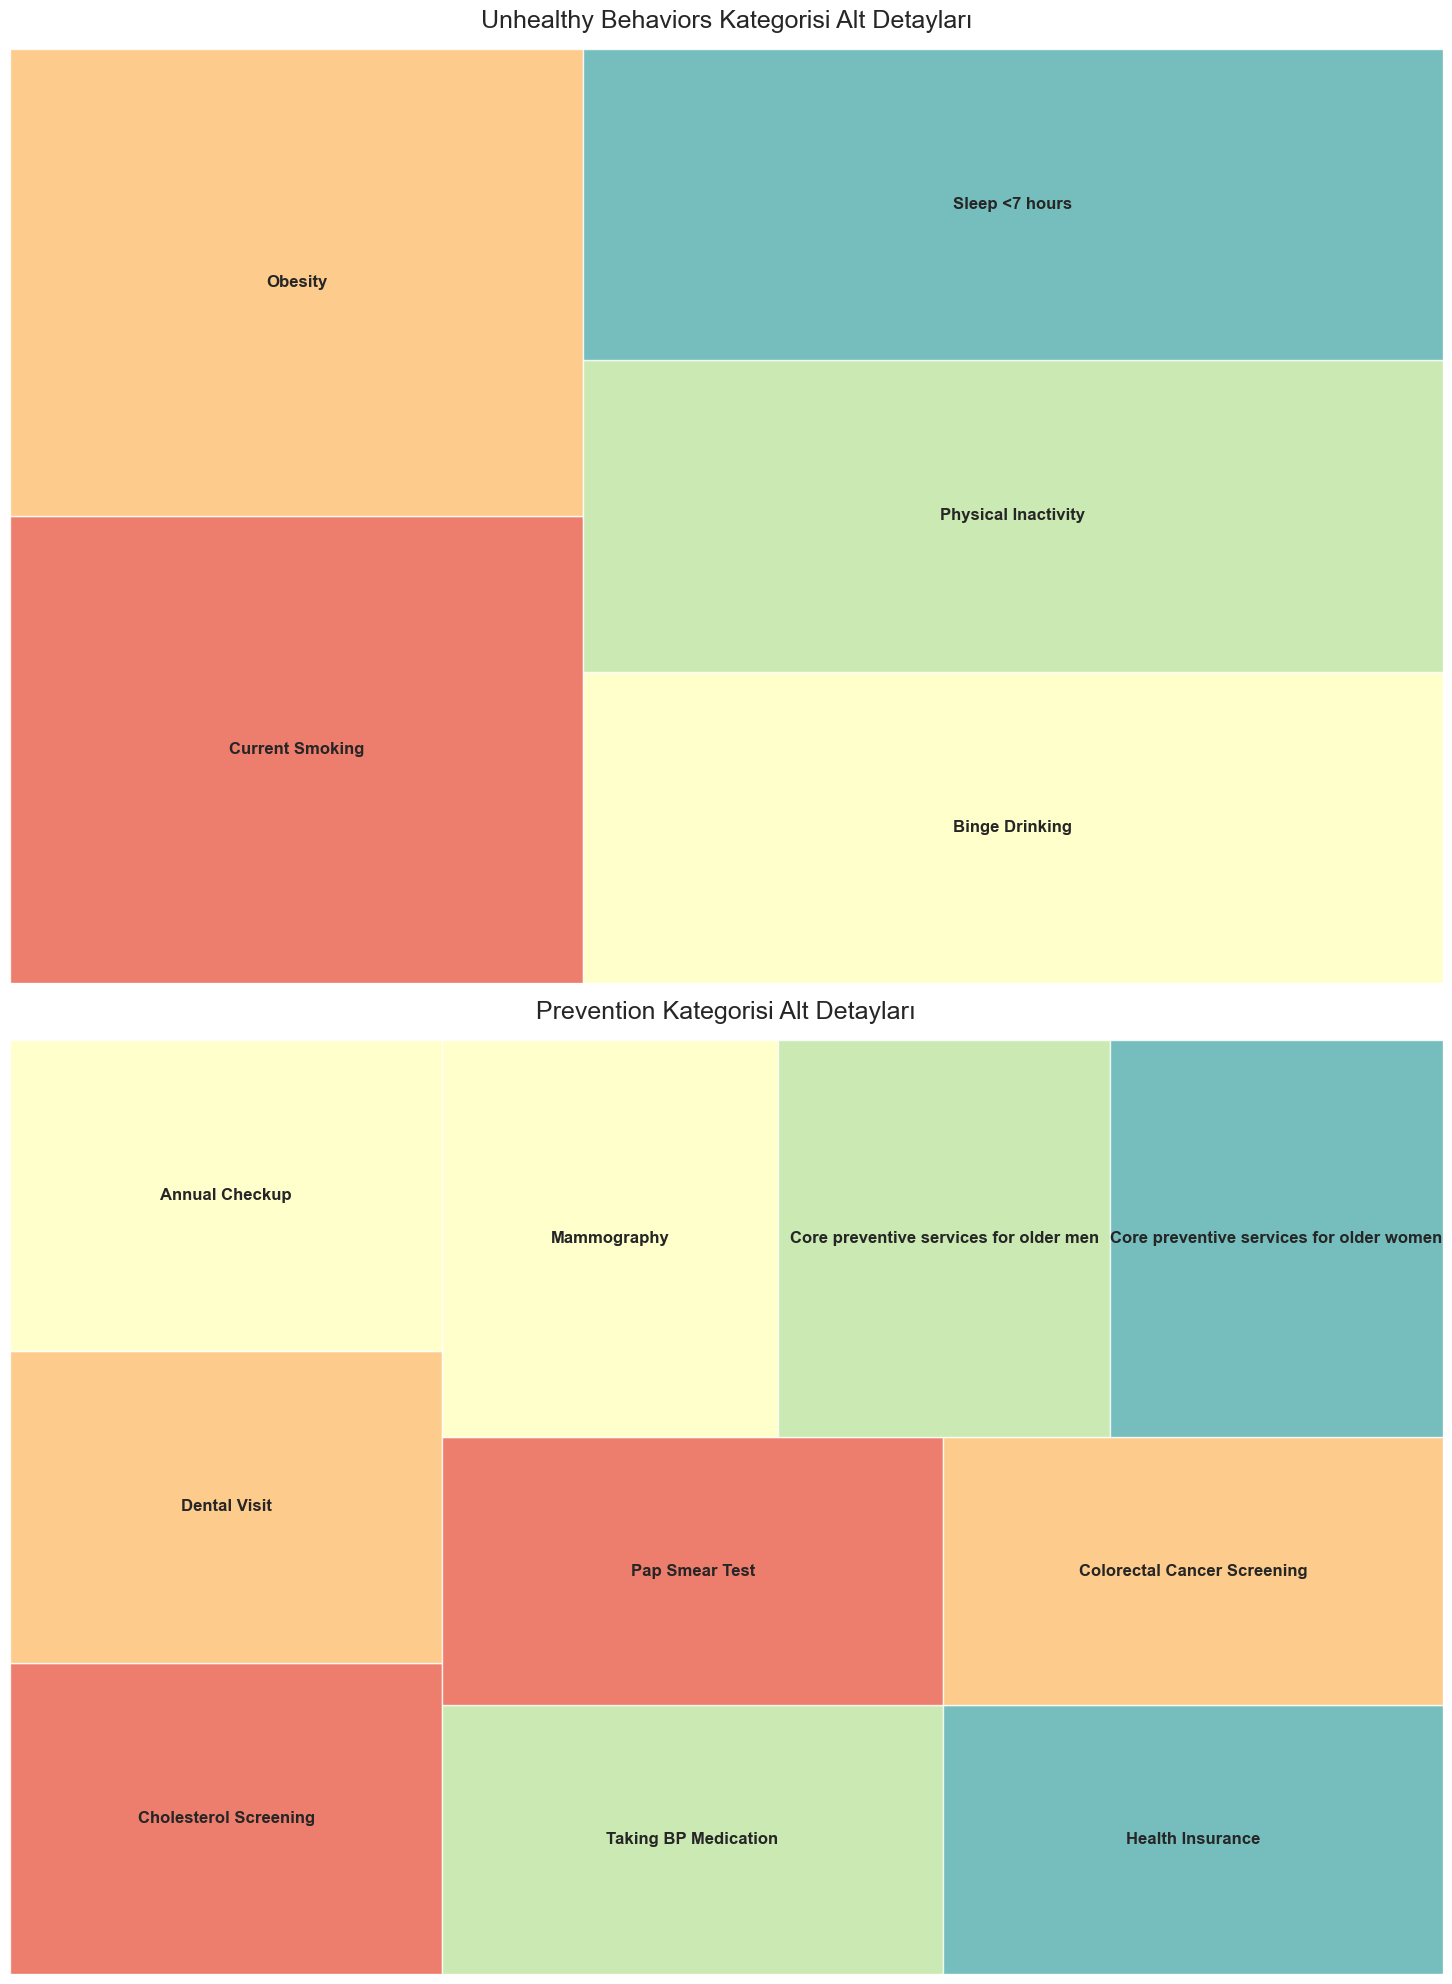

In [34]:
#Bu tree mapi diğer iki alt kategori içinde yapsak verinin büyüklüğünü daha iyi görebilirirz gibi

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 20)) # Grafiklerin yan yana/alt alta durması için

unhealthy = veri[veri['Category'] == 'Unhealthy Behaviors']['Short_Question_Text'].value_counts()  # Sağlıksız davranışları alıp
colors_u = sns.color_palette("Spectral", len(unhealthy)) # Spectral paleti ve uuzunluğa göre

squarify.plot(sizes=unhealthy.values, label=unhealthy.index, alpha=0.8,
              color=colors_u, ax=ax1, text_kwargs={'fontsize':12, 'fontweight':'bold'})
ax1.set_title('Unhealthy Behaviors Kategorisi Alt Detayları', fontsize=18, pad=15)
ax1.axis('off')


prevention = veri[veri['Category'] == 'Prevention']['Short_Question_Text'].value_counts() # Prevention
colors_p = sns.color_palette("Spectral", len(prevention))

squarify.plot(sizes=prevention.values, label=prevention.index, alpha=0.8,
              color=colors_u, ax=ax2, text_kwargs={'fontsize':12, 'fontweight':'bold'})
ax2.set_title('Prevention Kategorisi Alt Detayları', fontsize=18, pad=15)
ax2.axis('off')

plt.tight_layout()
plt.show()

In [36]:
import plotly.express as px  #plotly.express de grafik oluşturmak daha kolay

hedef_olcumler = ['Binge Drinking', 'Sleep <7 hours', 'Cancer (except skin)', 'Current Smoking', 'Obesity', 'Physical Inactivity']  #hangi featuersları 
#istiyorsak bir başlık altında birleştirdik
analiz_veri = veri[veri['Short_Question_Text'].isin(hedef_olcumler)]   #sonrasında short_question_text içindeki unhealty behaviour'ları 
#hedef ölçümlerdeki başlıkların altına tek tek yerleştirmesi için .isin kullandık

# Veriyi pivot hale getirmemiz gerek istediğimiz analiz için normalde bu başlıklar tek kolon altında biz bunları ayrı kolonlar 
#haline getireceğiz şehirlere, eyaletlere göre ki birbiri ile analiz yapabilelim
pivot_veri = analiz_veri.pivot_table(index=['CityFIPS', 'CityName', 'StateAbbr'],  
                                     columns='Short_Question_Text',
                                    values='Data_Value').reset_index()

pivot_veri = pivot_veri.dropna()    # bazı şehirlerde Boş veri vardı onları temizleyedik (korelasyonu bozmamaları için)

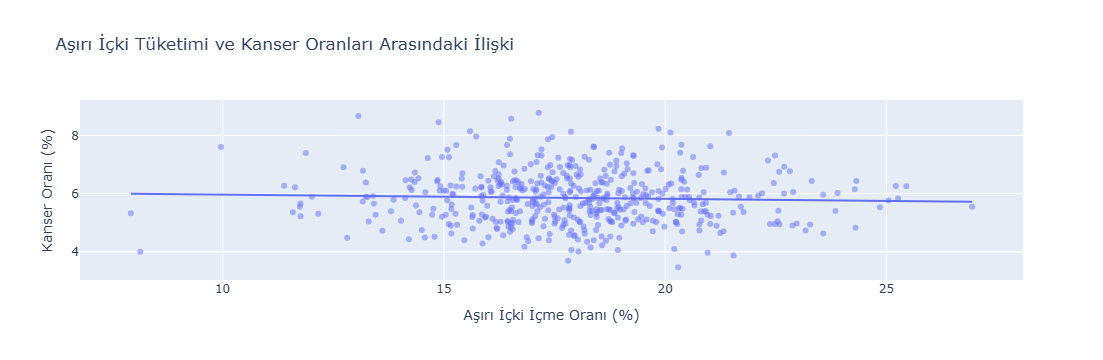

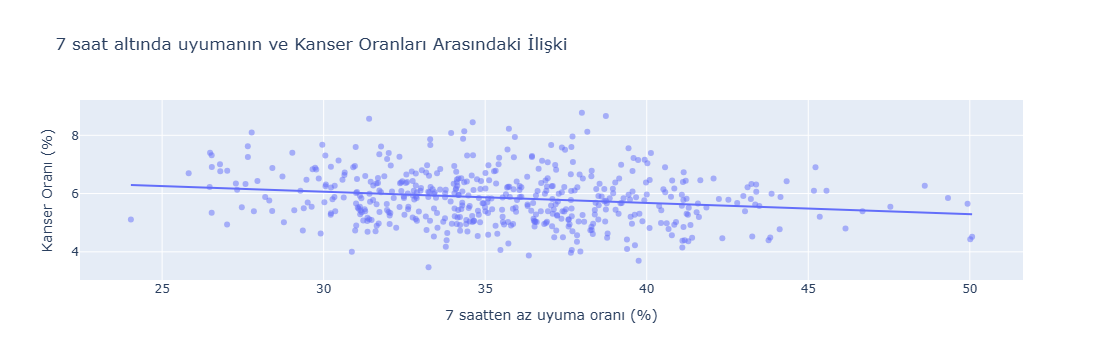

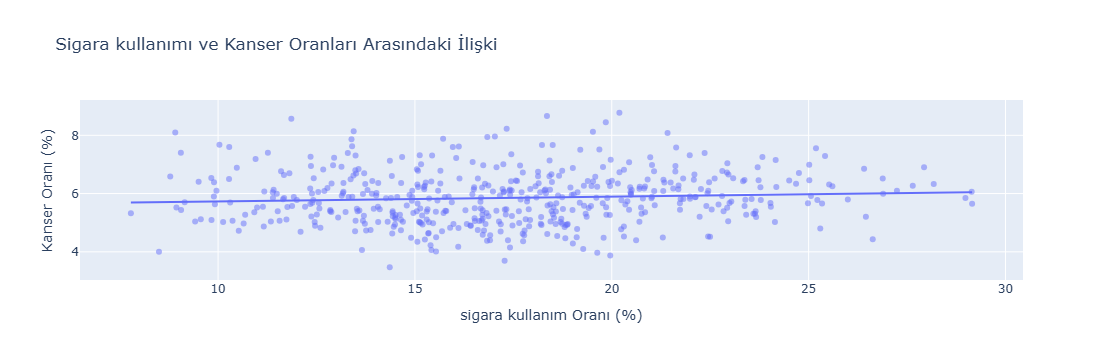

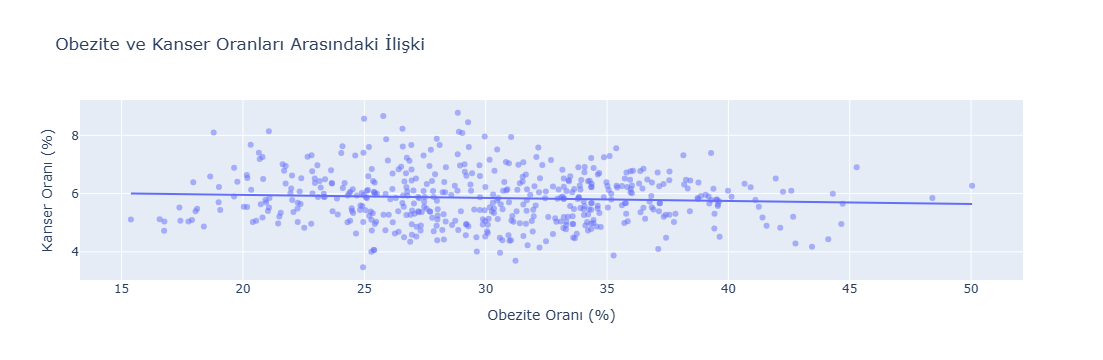

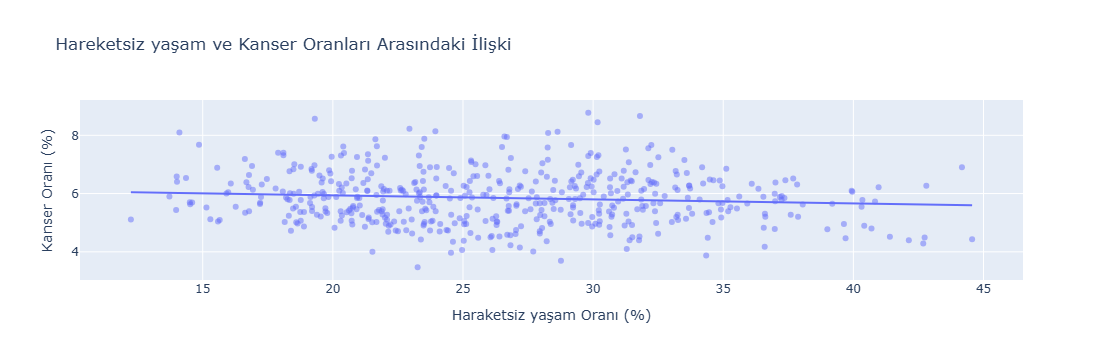

In [37]:
# Saçılım grafiklerini çizdik her bir unhealty behavior için
fig1 = px.scatter(pivot_veri, x='Binge Drinking', y='Cancer (except skin)',
                 trendline="ols", # regresyon çizgisi ekler
                 title='Aşırı İçki Tüketimi ve Kanser Oranları Arasındaki İlişki',
                 labels={'Binge Drinking':'Aşırı İçki İçme Oranı (%)', 'Cancer (except skin)':'Kanser Oranı (%)'},
                 hover_data=['CityName', 'StateAbbr'], # üzerine gelince şehir adını gösterir
                 opacity=0.5) # noktalar üst üste bindiğinde net görülsün diye

fig1.show()

fig2 = px.scatter(pivot_veri, x= 'Sleep <7 hours', y='Cancer (except skin)',
                 trendline="ols", # regresyon çizgisi ekler
                 title='7 saat altında uyumanın ve Kanser Oranları Arasındaki İlişki',
                 labels={'Sleep <7 hours':'7 saatten az uyuma oranı (%)', 'Cancer (except skin)':'Kanser Oranı (%)'},
                 hover_data=['CityName', 'StateAbbr'], # üzerine gelince şehir adını gösterir
                 opacity=0.5) # noktalar üst üste bindiğinde net görülsün diye

fig2.show()

fig3 = px.scatter(pivot_veri, x='Current Smoking', y='Cancer (except skin)',
                 trendline="ols", # regresyon çizgisi ekler
                 title='Sigara kullanımı ve Kanser Oranları Arasındaki İlişki',
                 labels={'Current Smoking':'sigara kullanım Oranı (%)', 'Cancer (except skin)':'Kanser Oranı (%)'},
                 hover_data=['CityName', 'StateAbbr'], # üzerine gelince şehir adını gösterir
                 opacity=0.5) # noktalar üst üste bindiğinde net görülsün diye

fig3.show()

fig4 = px.scatter(pivot_veri, x='Obesity', y='Cancer (except skin)',
                 trendline="ols", # regresyon çizgisi ekler
                 title='Obezite ve Kanser Oranları Arasındaki İlişki',
                 labels={'Obesity':'Obezite Oranı (%)', 'Cancer (except skin)':'Kanser Oranı (%)'},
                 hover_data=['CityName', 'StateAbbr'], # üzerine gelince şehir adını gösterir
                 opacity=0.5) # noktalar üst üste bindiğinde net görülsün diye

fig4.show()

fig5 = px.scatter(pivot_veri, x='Physical Inactivity', y='Cancer (except skin)',
                 trendline="ols", # regresyon çizgisi ekler
                 title='Hareketsiz yaşam ve Kanser Oranları Arasındaki İlişki',
                 labels={'Physical Inactivity':'Haraketsiz yaşam Oranı (%)', 'Cancer (except skin)':'Kanser Oranı (%)'},
                 hover_data=['CityName', 'StateAbbr'], # üzerine gelince şehir adını gösterir
                 opacity=0.5) # noktalar üst üste bindiğinde net görülsün diye opaklık ekliyoruz

fig5.show()


In [38]:
#muhtemelen veriyi yanlış yorumladım çünkü sağlıksız davranış arttıkça kanser oranı azalıyor gibi ama aralarında bir ilişki olduğu aşikar
#şehirlerdende kaynaklı olabilir bazı şehirlerde kanser oranı daha fazla ama buna sadece bu sağlıklsız davranışlar değil başka koşullarda etkiliyordur
#yinede veri yapısını tekrar incelemek istiyorum
pivot_veri.head(15)

Short_Question_Text,CityFIPS,CityName,StateAbbr,Binge Drinking,Cancer (except skin),Current Smoking,Obesity,Physical Inactivity,Sleep <7 hours
0,15003.00,Honolulu,HI,19.85,5.39,13.54,23.69,23.43,46.68
1,107000.00,Birmingham,AL,12.02,5.89,21.02,40.13,36.54,40.75
2,135896.00,Hoover,AL,15.42,6.70,13.71,29.44,24.65,33.51
3,137000.00,Huntsville,AL,13.17,6.78,18.74,36.07,31.18,38.30
4,150000.00,Mobile,AL,13.24,6.38,21.34,38.77,37.01,39.98
5,151000.00,Montgomery,AL,13.23,5.90,21.98,39.18,35.61,38.60
6,177256.00,Tuscaloosa,AL,14.74,5.28,19.86,37.42,33.25,39.63
7,203000.00,Anchorage,AK,20.21,5.46,17.89,34.26,20.91,31.27
8,404720.00,Avondale,AZ,17.95,4.57,17.78,30.94,26.82,37.84
9,412000.00,Chandler,AZ,18.48,5.85,14.39,26.30,20.93,34.80


In [39]:
pivot_veri.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CityFIPS              500 non-null    float64
 1   CityName              500 non-null    object 
 2   StateAbbr             500 non-null    object 
 3   Binge Drinking        500 non-null    float64
 4   Cancer (except skin)  500 non-null    float64
 5   Current Smoking       500 non-null    float64
 6   Obesity               500 non-null    float64
 7   Physical Inactivity   500 non-null    float64
 8   Sleep <7 hours        500 non-null    float64
dtypes: float64(7), object(2)
memory usage: 35.3+ KB


In [43]:
pivot_descriptive = pivot_veri.describe().T
pivot_descriptive


,count,mean,std,min,25%,50%,75%,max
Short_Question_Text,,,,,,,,
CityFIPS,500.00,2438986.28,1720294.18,15003.00,670073.50,1955965.00,4053125.00,5613900.00
Binge Drinking,500.00,17.97,2.61,7.93,16.45,17.89,19.48,26.93
Cancer (except skin),500.00,5.85,0.89,3.47,5.21,5.83,6.39,8.77
Current Smoking,500.00,17.35,4.22,7.79,14.36,17.25,20.24,29.15
Obesity,500.00,30.00,6.04,15.38,25.43,29.98,34.23,50.04
Physical Inactivity,500.00,26.44,6.41,12.24,21.37,26.13,31.00,44.56
Sleep <7 hours,500.00,35.57,4.34,24.03,32.56,35.30,38.31,50.07


In [46]:
#bide sadece multible lineer regresyon kuracağı basit olarak 
from sklearn.linear_model import LinearRegression

# bağımsız değişken =X, bağımlı değişken=Y
X = pivot_veri[['Binge Drinking', 'Sleep <7 hours', 'Current Smoking', 'Obesity', 'Physical Inactivity']] # Dahil edilecek sağlıksız davranışlar
y = pivot_veri['Cancer (except skin)']

model = LinearRegression()  #model
model.fit(X, y) #bütün veri setinde eğitiyoruz

intercept = model.intercept_ #intercept ve katsayılarını istediğimizi belirttik
coefficients = model.coef_

katsayi_tablosu = pd.DataFrame({'Değişkenler': X.columns, 'Katsayı': coefficients}) #tabloda görmek için
print(f"Sabit Terim (Intercept): {intercept:.3f}")
print("\nDeğişkenlerin Kanser Üzerindeki Etkisi:")
print(katsayi_tablosu)   

r2_score = model.score(X, y)    #modelin açıklama oranıda düşük
print(f"\nR²: %{r2_score*100:.2f}")

Sabit Terim (Intercept): 9.920

Değişkenlerin Kanser Üzerindeki Etkisi:
           Değişkenler  Katsayı
0       Binge Drinking    -0.09
1       Sleep <7 hours    -0.08
2      Current Smoking     0.16
3              Obesity    -0.04
4  Physical Inactivity    -0.05

R²: %19.72
